## Analyse impact of contrail-sensitive regions on airspace capacity

1. Download gridded CoCiP regions - see 3_issr.ipynb for more info
2. 

In [ ]:
import numpy as np
import pandas as pd
import shapely
import regionmask
from scipy import ndimage
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import glob
import os
import xarray as xr
import json, topojson, geopandas as gpd, regionmask

# ---------------------------------------
# CONFIGURATION
# ---------------------------------------
input_pattern = "GriddedCoCip/2024*.nc"  # adjust this path
output_file = "airspace_capacity.parquet"
n_workers = 8  # use all but one core

R = 6371.0  # Earth radius in km


regions = { 
    "Global": {"lon_min": -180, "lon_max": 180, "lat_min": -90, "lat_max": 90},
    "USA": {"lon_min": -126, "lon_max": -66, "lat_min": 23, "lat_max": 50},
    "Europe": {"lon_min": -12, "lon_max": 20, "lat_min": 35, "lat_max": 60}, 
    "East_Asia": {"lon_min": 103, "lon_max": 150, "lat_min": 15, "lat_max": 48},
    "Southeast_Asia": {"lon_min": 87.5, "lon_max": 130, "lat_min": -10, "lat_max": 20},
    "Latin_America": {"lon_min": -85, "lon_max": -35, "lat_min": -60, "lat_max": 15}, 
    "Africa_Middle_East": {"lon_min": -20, "lon_max": 50, "lat_min": -35, "lat_max": 40}, 
    "China": {"lon_min": 73.5, "lon_max": 135, "lat_min": 18, "lat_max": 53.5}, 
    "India": {"lon_min": 68, "lon_max": 97.5, "lat_min": 8, "lat_max": 35.5}, 
    "North Atlantic": {"lon_min": -70, "lon_max": -5, "lat_min": 40, "lat_max": 63}, 
    "North Pacific": {"lon_min": 140, "lon_max": -120, "lat_min": 35, "lat_max": 65}, 
    "Arctic": {"lon_min": -180, "lon_max": 180, "lat_min": 66.5, "lat_max": 90}, 
    "Eurocontrol": { "lon_min": -30.0, "lon_max": 45.0, "lat_min": 25.0, "lat_max": 72.0 } 
}

    
with open(r"worldfirs.json", "r", encoding="utf-8") as f:
    data = json.load(f)
    
topo = topojson.Topology(data, object_name="data")
gdf = topo.to_gdf().set_crs(epsg=4326)

gdf = gdf[gdf["type"].str.upper() == "FIR"]


# Filter out European FIRs
european_fir = pd.read_csv("data/european_firs.csv")
gdf = gdf[gdf["designator"].isin(european_fir["FIR code"])]

# build FIR regionmask
firs_mask = regionmask.Regions(name="FIRs",
                                outlines=gdf.geometry.values,
                                names=gdf["name"].tolist(),
                                abbrevs=gdf["name"].tolist())


           
# ---------------------------------------
# HELPER FUNCTION
# ---------------------------------------

def process_file(filepath):
    """
    Compute % of airspace volume above/below EFcontrail thresholds
    for each region (rectangular + FIR) and flight level.

    Cases:
      1. Negative forcing (EF < 0)
      2. Non-zero forcing (EF != 0)
      3. Positive forcing (EF > 0)
      4. > 5e8 J/m (80th percentile)
      5. > 1.54e9 J/m (95th percentile)
    """
    try:
        # ---------------------------------------------
        # 1️⃣ Load EF dataset
        # ---------------------------------------------
        ds = xr.open_dataset(filepath)
        ds_hr = ds.isel(time=0)
        ef = ds_hr["ef_per_m"].transpose("latitude", "longitude", "flight_level")

        lat = ef.latitude.values
        lon = ef.longitude.values
        lev = ef.flight_level.values
        time = pd.to_datetime(str(ds.time.values[0]))

        # sort by longitude
        ef = ef.assign_coords(longitude=lon).sortby("longitude")
        ef_data = ef.values
        valid_mask = np.isfinite(ef_data)

        
        # apply FIR mask to lat/lon grid
        mask_fir = firs_mask.mask(lon, lat).values  # (lat, lon)


        # ---------------------------------------------
        # 2️⃣ Grid cell area & vertical thickness
        # ---------------------------------------------
        R = 6371.0  # Earth radius in km
        dlat = np.deg2rad(np.abs(np.diff(lat)).mean())
        dlon = np.deg2rad(np.abs(np.diff(lon)).mean())
        lat_rad = np.deg2rad(lat)
        cell_area_lat = (R**2) * dlat * dlon * np.cos(lat_rad)
        area_2d = np.repeat(cell_area_lat[:, None], len(lon), axis=1)
        area_3d = np.repeat(area_2d[:, :, None], ef.shape[2], axis=2)

        fl_ft = lev * 100.0
        fl_m = fl_ft * 0.3048
        dz = np.mean(np.diff(fl_m)) if len(fl_m) > 1 else 0.0

        # ---------------------------------------------
        # 3️⃣ Define forcing category masks
        # ---------------------------------------------
        masks = {
            "Negative": (ef_data < 0) & valid_mask,
            "Non-zero": (ef_data != 0) & valid_mask,
            "Positive": (ef_data > 0) & valid_mask,
            "+80th-percentile": (ef_data > 5e8) & valid_mask,
            "+95th-percentile": (ef_data > 1.54e9) & valid_mask,
        }

        records = []

        # ---------------------------------------------
        # 4️⃣ RECTANGULAR REGIONS (existing)
        # ---------------------------------------------
        for reg_name, bounds in regions.items():
            lon_min, lon_max = bounds["lon_min"], bounds["lon_max"]
            lat_min, lat_max = bounds["lat_min"], bounds["lat_max"]

            # Handle dateline crossing
            if lon_min < lon_max:
                lon_mask = (lon >= lon_min) & (lon <= lon_max)
            else:
                lon_mask = (lon >= lon_min) | (lon <= lon_max)

            lat_mask = (lat >= lat_min) & (lat <= lat_max)
            reg_mask2d = np.outer(lat_mask, lon_mask)
            reg_mask3d = np.repeat(reg_mask2d[:, :, None], ef.shape[2], axis=2)

            reg_valid = valid_mask & reg_mask3d

            for case, case_mask in masks.items():
                reg_case = case_mask & reg_mask3d
                for i, level in enumerate(lev):
                    area_total = np.nansum(area_3d[:, :, i][reg_valid[:, :, i]])
                    area_case  = np.nansum(area_3d[:, :, i][reg_case[:, :, i]])
                    vol_total  = area_total * dz / 1000.0
                    vol_case   = area_case * dz / 1000.0

                    records.append({
                        "time": time,
                        "file": filepath,
                        "region": reg_name,
                        "flight_level": level,
                        "forcing_case": case,
                        "vol_total_km3": vol_total,
                        "vol_case_km3": vol_case,
                    })

        # ---------------------------------------------
        # 5️⃣ FIR REGIONS (Topological polygons)
        # ---------------------------------------------
        try:
            for idx, fir_name in enumerate(firs_mask.names):
                fir_mask2d = mask_fir == idx
                if not np.any(fir_mask2d):
                    continue

                fir_mask3d = np.repeat(fir_mask2d[:, :, None], ef.shape[2], axis=2)
                reg_valid = valid_mask & fir_mask3d

                for case, case_mask in masks.items():
                    reg_case = case_mask & fir_mask3d
                    for i, level in enumerate(lev):
                        area_total = np.nansum(area_3d[:, :, i][reg_valid[:, :, i]])
                        area_case  = np.nansum(area_3d[:, :, i][reg_case[:, :, i]])
                        vol_total  = area_total * dz / 1000.0
                        vol_case   = area_case * dz / 1000.0

                        records.append({
                            "time": time,
                            "file": filepath,
                            "region": fir_name,
                            "flight_level": level,
                            "forcing_case": case,
                            "vol_total_km3": vol_total,
                            "vol_case_km3": vol_case,
                        })

        except Exception as e:
            print(f"⚠️ FIR processing skipped for {filepath}: {e}")

        # ---------------------------------------------
        # 6️⃣ Combine and return
        # ---------------------------------------------
        ds.close()
        return pd.DataFrame(records)

    except Exception as e:
        print(f"⚠️ Error processing {filepath}: {e}")
        import traceback; traceback.print_exc(limit=1)
        return pd.DataFrame([])



In [ ]:
import traceback

# ---------------------------------------
# MAIN EXECUTION BLOCK 
# ---------------------------------------
def main():

    files = sorted(glob.glob(input_pattern))
    print(f"Found {len(files)} hourly files.")
    if not files:
        print("⚠️ No files matched the pattern.")
        return

    # --- optional: resume capability ---
    if os.path.exists(output_file):
        existing = pd.read_parquet(output_file)
        done_files = set(existing["file"].unique())
        files = [f for f in files if os.path.basename(f) not in done_files]
        all_dfs = [existing]
        print(f"Resuming from previous run: {len(done_files)} already processed.")
    else:
        all_dfs = []
        done_files = set()

    n_total = len(files)
    if n_total == 0:
        print("✅ All files already processed.")
        return

    # --- partial save configuration ---
    save_every = 20  # save every N files
    temp_file = output_file.replace(".parquet", "_partial.parquet")

    try:
        with ProcessPoolExecutor(max_workers=n_workers) as executor:
            futures = {executor.submit(process_file, f): f for f in files}
            processed = 0

            for fut in tqdm(as_completed(futures), total=n_total, desc="Processing files"):
                filepath = futures[fut]
                try:
                    df_part = fut.result()
                    if not df_part.empty:
                        all_dfs.append(df_part)
                        done_files.add(os.path.basename(filepath))
                except Exception as e:
                    print(f"⚠️ Failure in {filepath}: {e}")
                    traceback.print_exc(limit=1)
                    continue

                processed += 1
                # --- periodic save ---
                if processed % save_every == 0:
                    try:
                        df_temp = pd.concat(all_dfs, ignore_index=True)
                        df_temp.to_parquet(temp_file, index=False)
                        print(f"💾 Saved interim results ({processed}/{n_total}) to {temp_file}")
                    except Exception as e:
                        print(f"⚠️ Could not save interim parquet: {e}")

    except KeyboardInterrupt:
        print("\n⛔ Interrupted by user. Saving current progress...")
    except Exception as e:
        print(f"❌ Unexpected error in main loop: {e}")
    finally:
        # --- final save ---
        if all_dfs:
            df_final = pd.concat(all_dfs, ignore_index=True)
            df_final.to_parquet(output_file, index=False)
            print(f"✅ Saved {len(df_final)} total region records to {output_file}")
        else:
            print("⚠️ No valid data processed (nothing to save).")



# ---------------------------------------
# ENTRY POINT (required for multiprocessing)
# ---------------------------------------
if __name__ == "__main__":
    main()

In [10]:
import pandas as pd

df = pd.read_parquet("output/airspace_capacity.parquet")

In [7]:
df.head()

,time,file,region,region_type,flight_level,forcing_case,pct_area,pct_volume,area_total_km2,area_case_km2,vol_total_km3,vol_case_km3
0,2024-01-01 05:00:00,20240101T05.nc,USA,RectBox,270,Negative,0.006657,0.006657,16164848.0,1076.0420,4.927046e+06,327.977599
1,2024-01-01 05:00:00,20240101T05.nc,USA,RectBox,280,Negative,0.016604,0.016604,16164848.0,2684.0437,4.927046e+06,818.096520
2,2024-01-01 05:00:00,20240101T05.nc,USA,RectBox,290,Negative,0.000000,0.000000,16164848.0,0.0000,4.927046e+06,0.000000
3,2024-01-01 05:00:00,20240101T05.nc,USA,RectBox,300,Negative,0.000000,0.000000,16164848.0,0.0000,4.927046e+06,0.000000
4,2024-01-01 05:00:00,20240101T05.nc,USA,RectBox,310,Negative,0.000000,0.000000,16164848.0,0.0000,4.927046e+06,0.000000


In [11]:
import pandas as pd

# assuming df is your DataFrame
df['time'] = pd.to_datetime(df['time'])

# group by time, region, and forcing_case
df_capacity = (
    df.groupby(['time', 'region', 'forcing_case'])
      .agg({
          'vol_case_km3': 'sum',      # occupied volume
          'vol_total_km3': 'sum'    # total capacity (same for all rows in group)
      })
      .reset_index()
)

# compute percentage or fraction of capacity used
df_capacity['occupied_capacity'] = df_capacity['vol_case_km3'] / df_capacity['vol_total_km3']


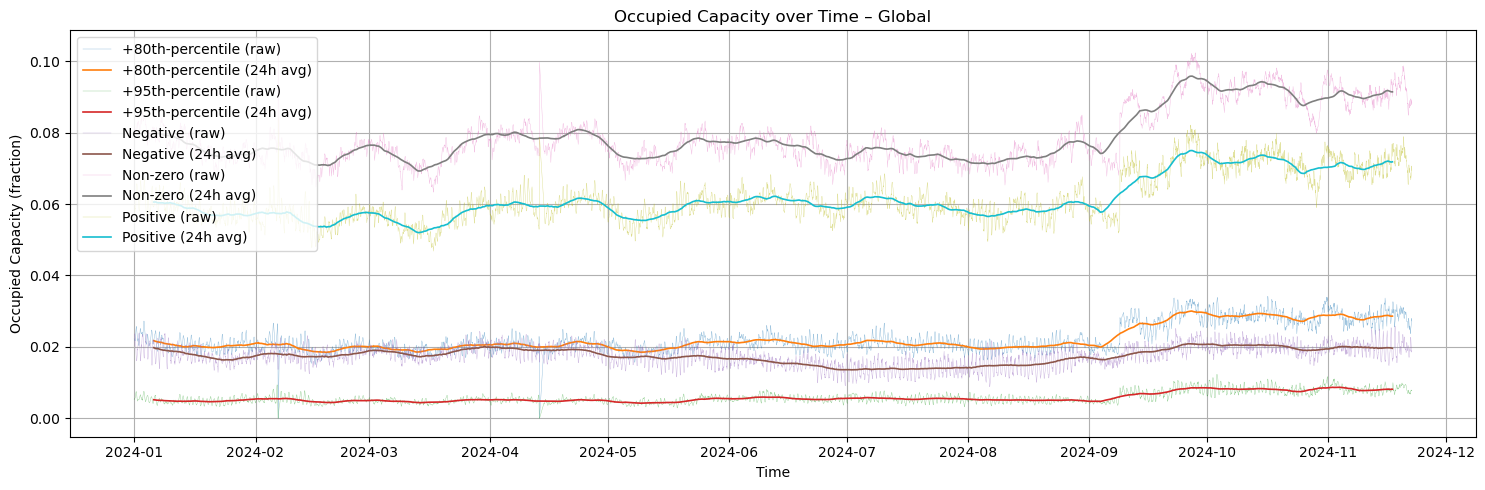

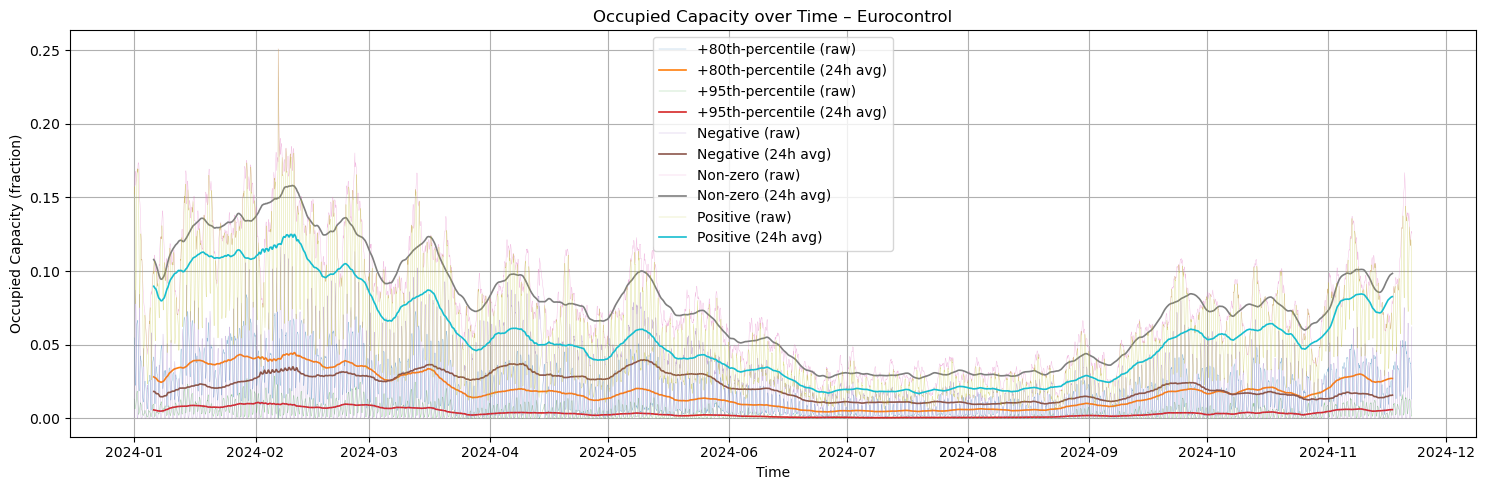

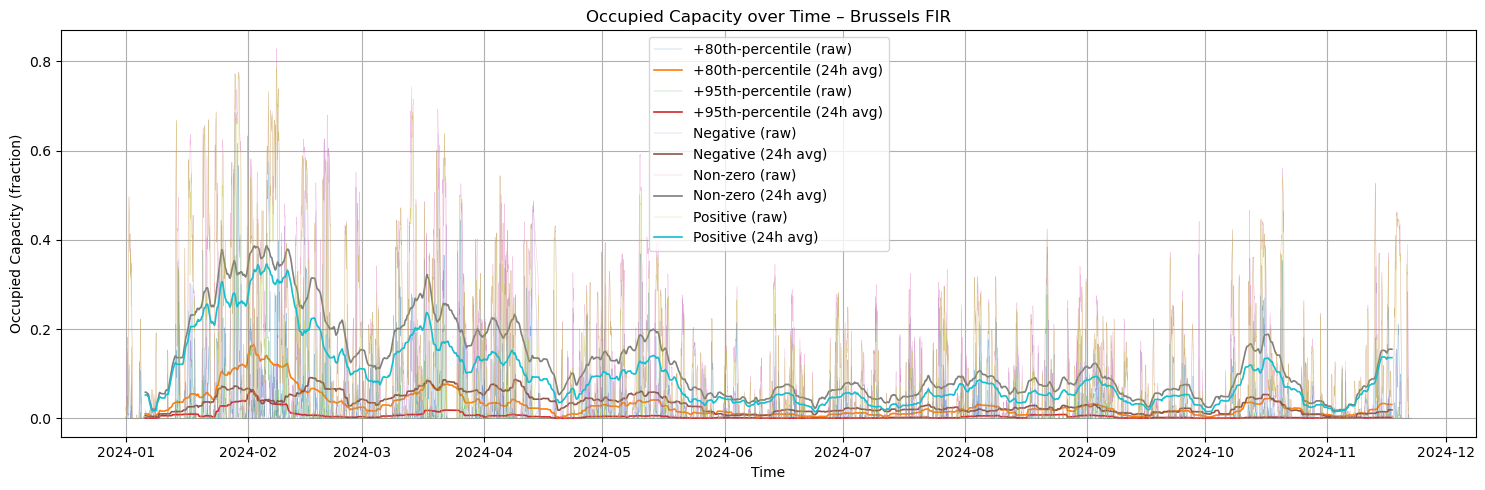

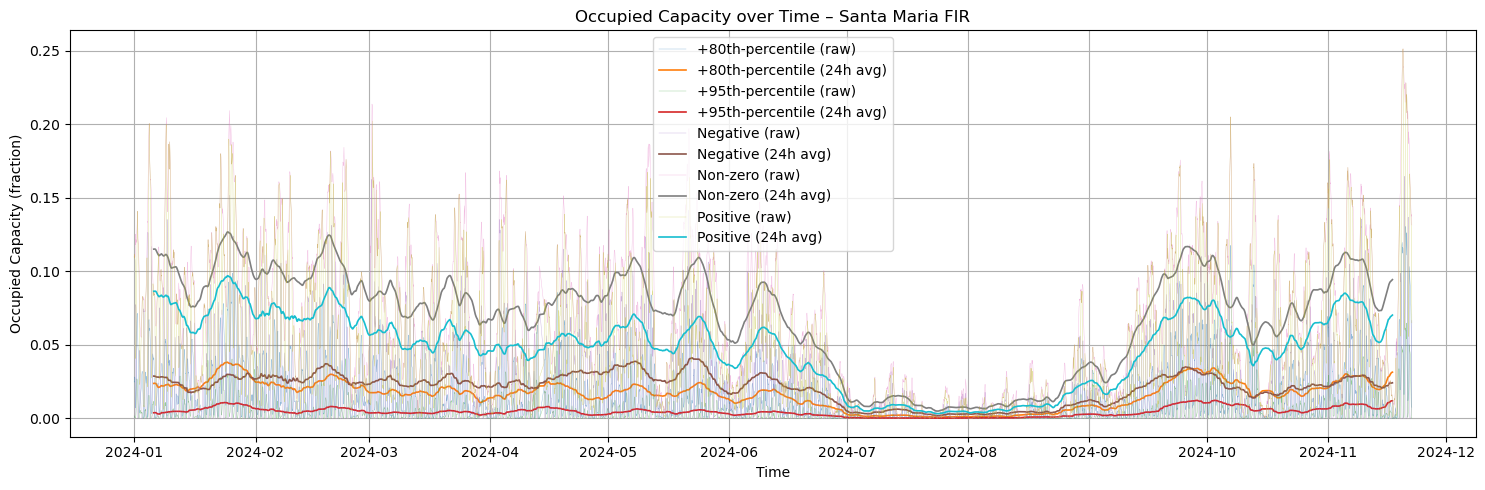

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

regions = df_capacity['region'].unique()

regions = ["Global", "Eurocontrol", "Brussels FIR", "Santa Maria FIR"]
for region in regions:
    fig, ax = plt.subplots(figsize=(15, 5))
    region_data = df_capacity[df_capacity['region'] == region]

    # Ensure the time column is datetime and sorted
    region_data = region_data.sort_values('time')
    region_data['time'] = pd.to_datetime(region_data['time'])

    for case, grp in region_data.groupby('forcing_case'):
        grp = grp.set_index('time')

        # Apply a 24-hour (24 observation) rolling mean
        grp['occupied_capacity_smooth'] = grp['occupied_capacity'].rolling(window=240, center=True).mean()

        # Plot both raw and smoothed data
        ax.plot(grp.index, grp['occupied_capacity'], label=f'{case} (raw)', lw=0.3, alpha=0.5)
        ax.plot(grp.index, grp['occupied_capacity_smooth'], label=f'{case} (24h avg)', lw=1.2)

    ax.set_title(f'Occupied Capacity over Time – {region}')
    ax.set_ylabel('Occupied Capacity (fraction)')
    ax.set_xlabel('Time')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


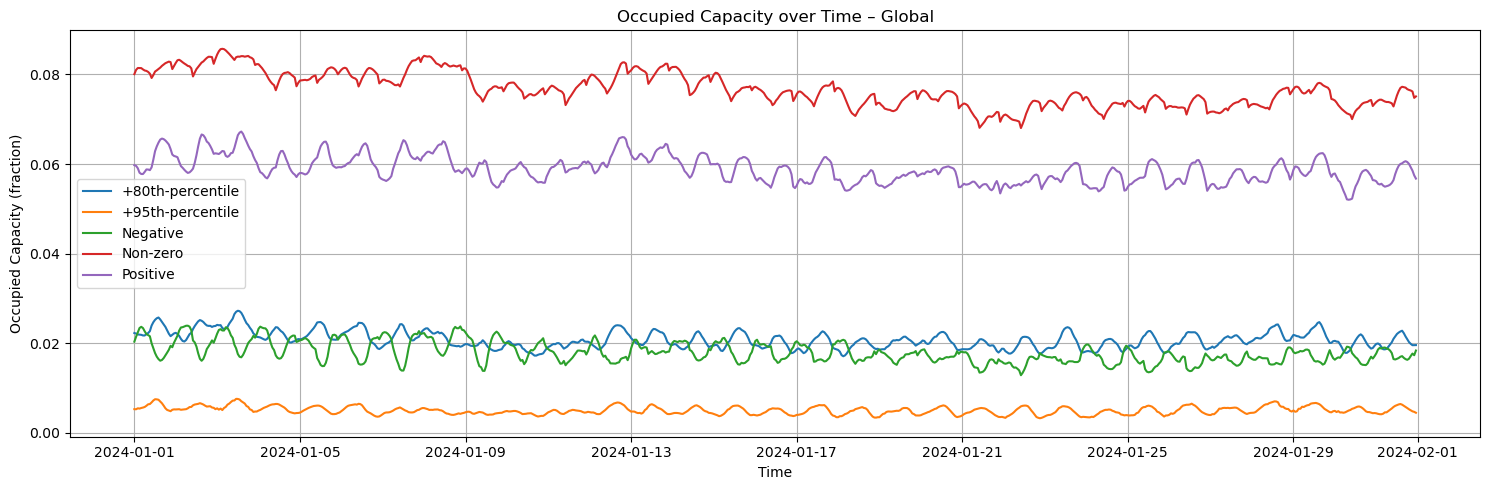

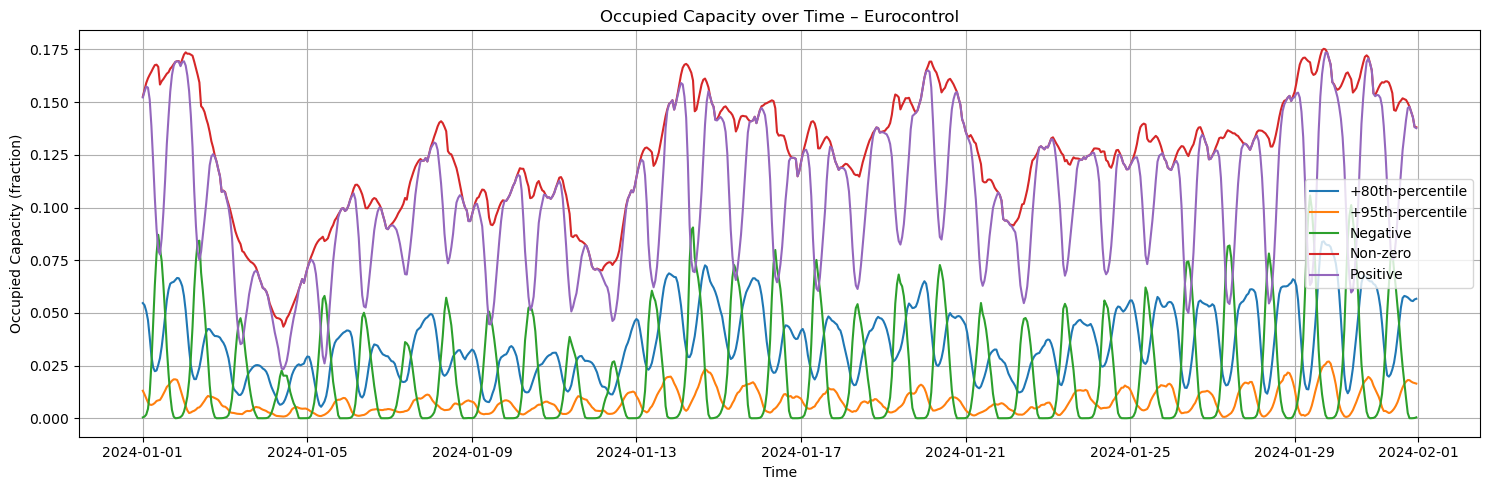

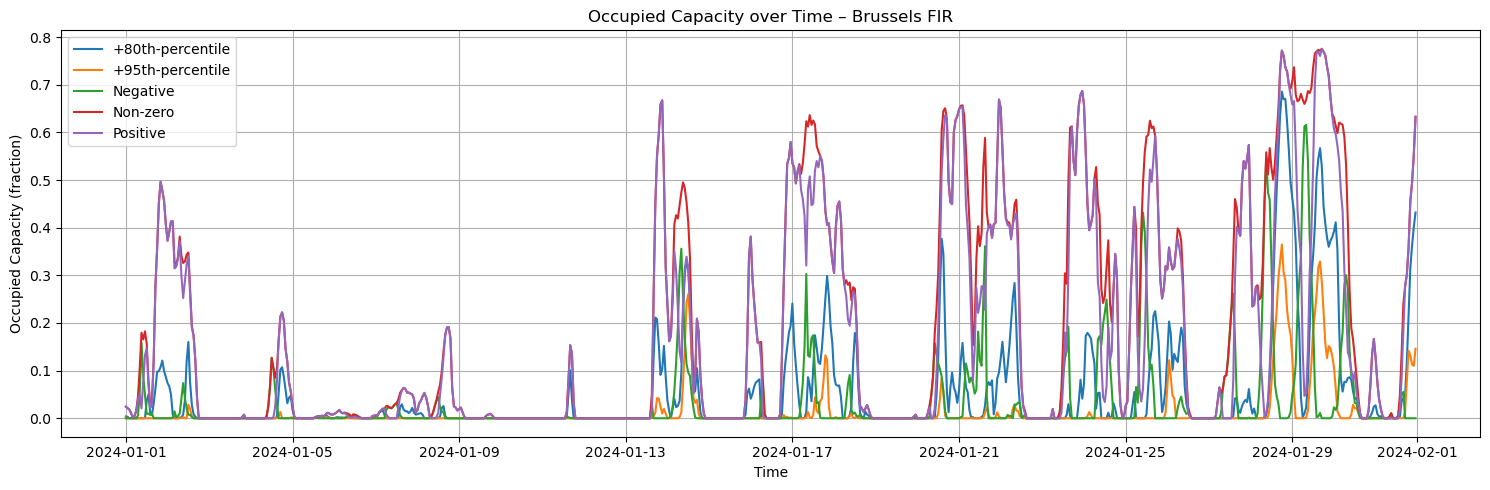

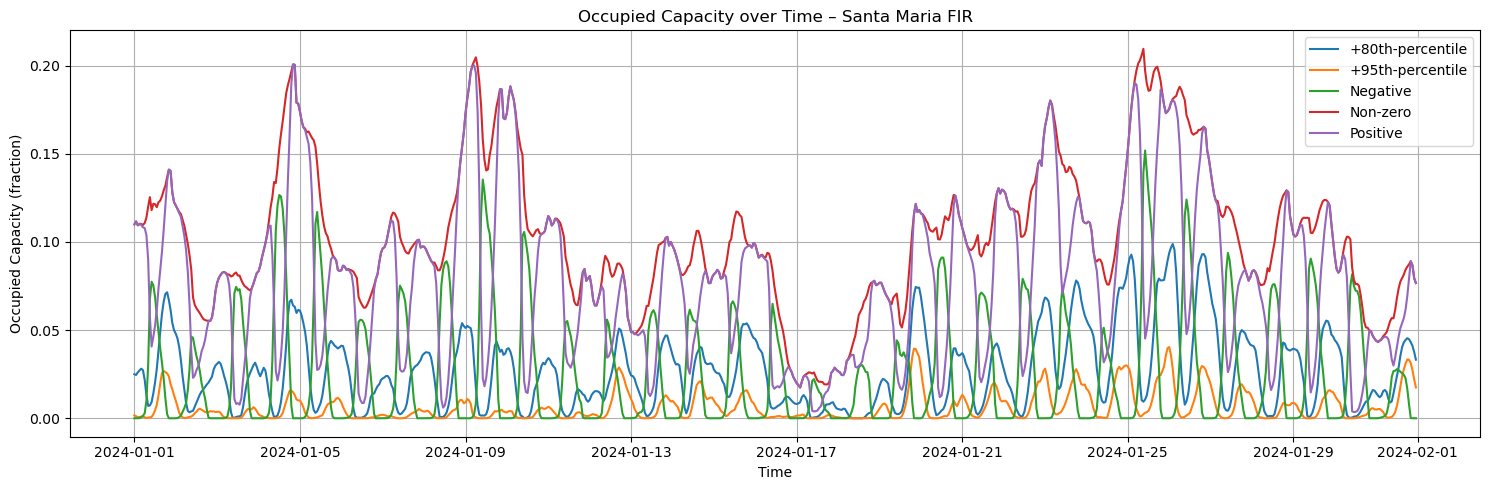

In [30]:
import matplotlib.pyplot as plt

regions = df_capacity['region'].unique()

regions = ["Global", "Eurocontrol", "Brussels FIR", "Santa Maria FIR"]
n_regions = len(regions)


for region in regions:
    fig, ax = plt.subplots(figsize=(15, 5))
    region_data = df_capacity[df_capacity['region'] == region]
    for case, grp in region_data.groupby('forcing_case'):
        ax.plot(grp['time'][:24*31], grp['occupied_capacity'][:24*31], label=case)
    ax.set_title(f'Occupied Capacity over Time – {region}')
    ax.set_ylabel('Occupied Capacity (fraction)')
    ax.legend()
    ax.grid(True)

    plt.xlabel('Time')
    plt.tight_layout()
    plt.show()


In [32]:
import pandas as pd

# assuming df is your DataFrame
df['time'] = pd.to_datetime(df['time'])
df_80      = df[df["forcing_case"]=="+80th-percentile"]
# group by time, region, and forcing_case
df_capacity = (
    df_80.groupby(['time', 'region', 'flight_level'])
      .agg({
          'vol_case_km3': 'sum',      # occupied volume
          'vol_total_km3': 'sum'    # total capacity (same for all rows in group)
      })
      .reset_index()
)

# compute percentage or fraction of capacity used
df_capacity['occupied_capacity'] = df_capacity['vol_case_km3'] / df_capacity['vol_total_km3']


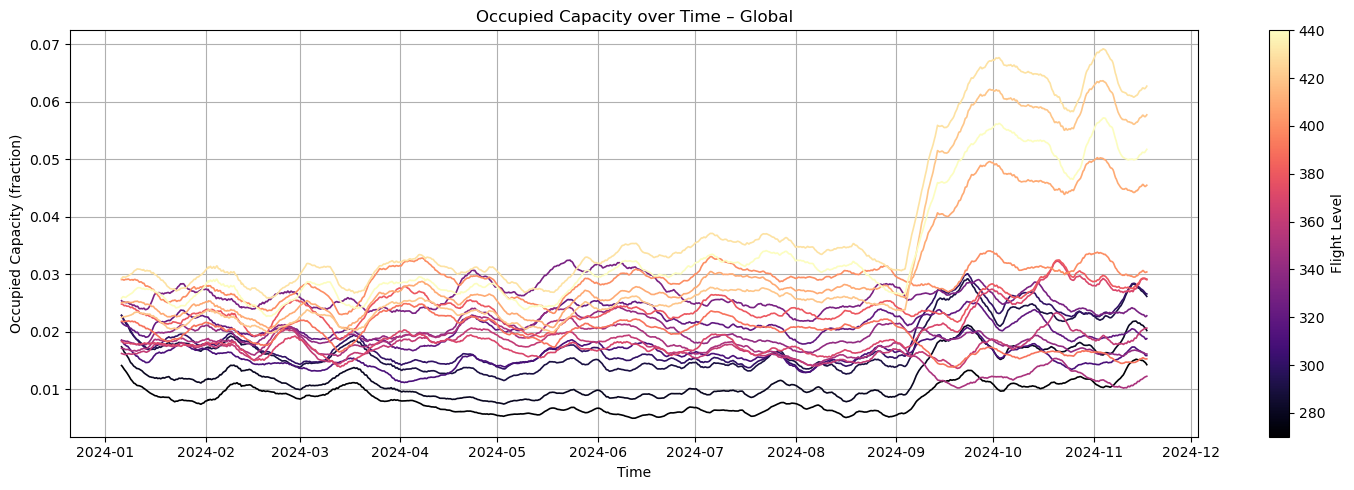

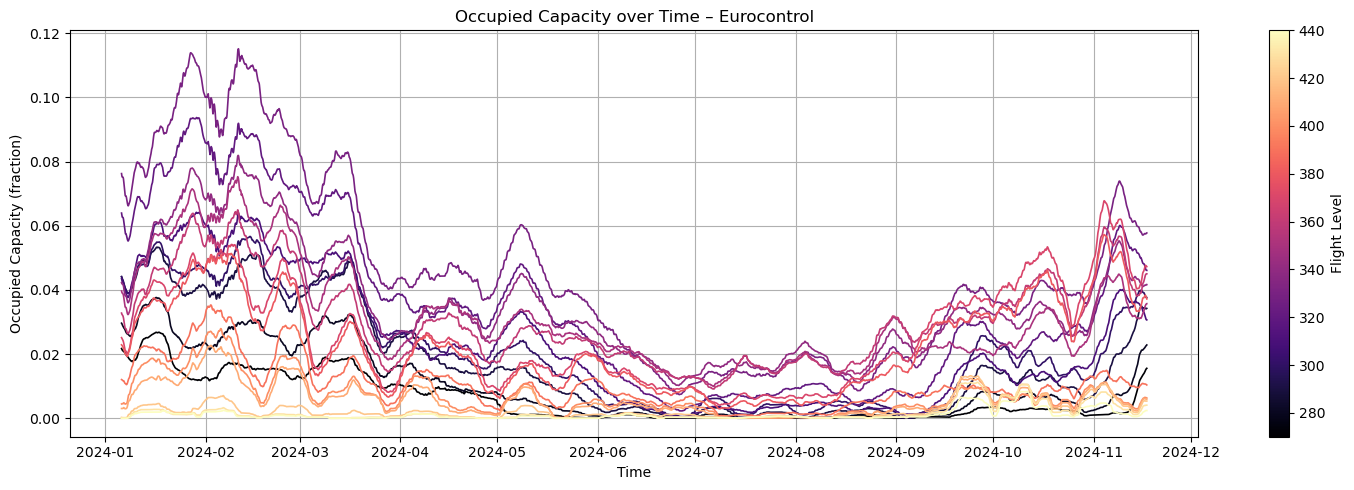

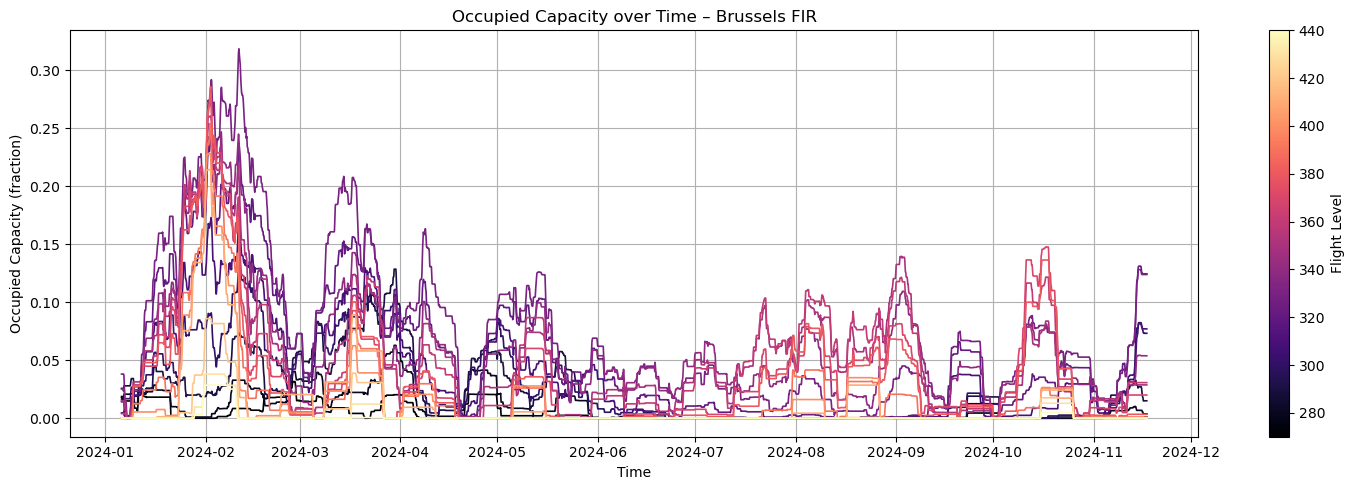

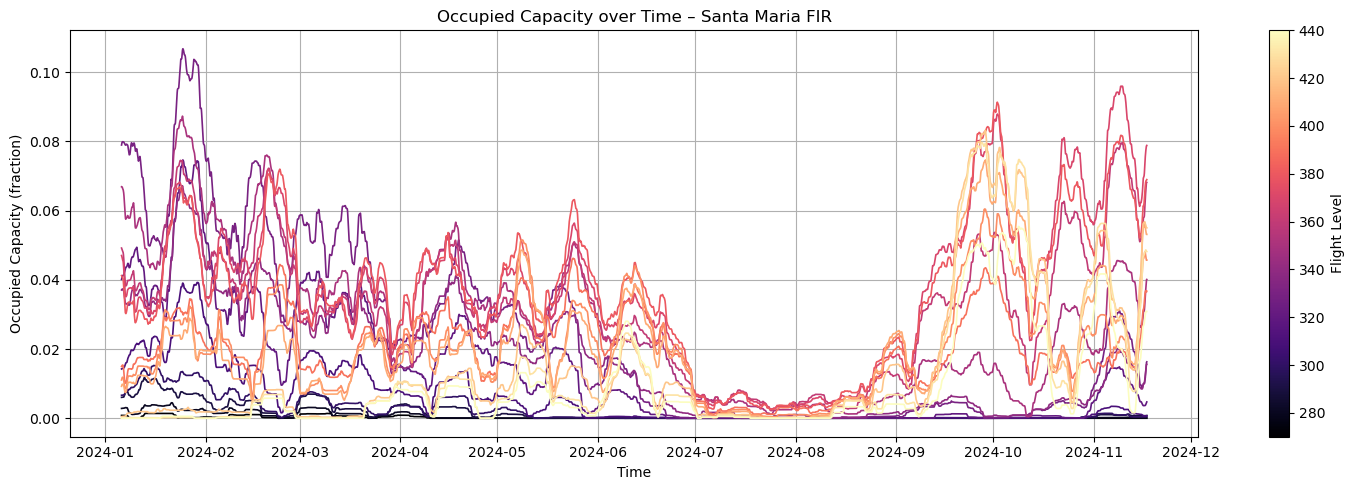

In [36]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

regions = ["Global", "Eurocontrol", "Brussels FIR", "Santa Maria FIR"]

# Define the colormap
cmap = plt.cm.magma

for region in regions:
    fig, ax = plt.subplots(figsize=(15, 5))
    region_data = df_capacity[df_capacity['region'] == region]

    # Ensure the time column is datetime and sorted
    region_data = region_data.sort_values('time')
    region_data['time'] = pd.to_datetime(region_data['time'])

    # Get unique flight levels and normalize for color mapping
    flight_levels = sorted(region_data['flight_level'].unique())
    norm = mpl.colors.Normalize(vmin=min(flight_levels), vmax=max(flight_levels))

    for case, grp in region_data.groupby('flight_level'):
        grp = grp.set_index('time')

        # Apply a rolling mean
        grp['occupied_capacity_smooth'] = grp['occupied_capacity'].rolling(window=240, center=True).mean()

        # Determine the color for this flight level
        color = cmap(norm(case))

        # Plot smoothed line (no legend)
        ax.plot(grp.index, grp['occupied_capacity_smooth'], lw=1.2, color=color)

    # Add title and labels
    ax.set_title(f'Occupied Capacity over Time – {region}')
    ax.set_ylabel('Occupied Capacity (fraction)')
    ax.set_xlabel('Time')
    ax.grid(True)

    # Add colorbar for flight levels
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # only needed for the colorbar
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
    cbar.set_label('Flight Level')

    plt.tight_layout()
    plt.show()


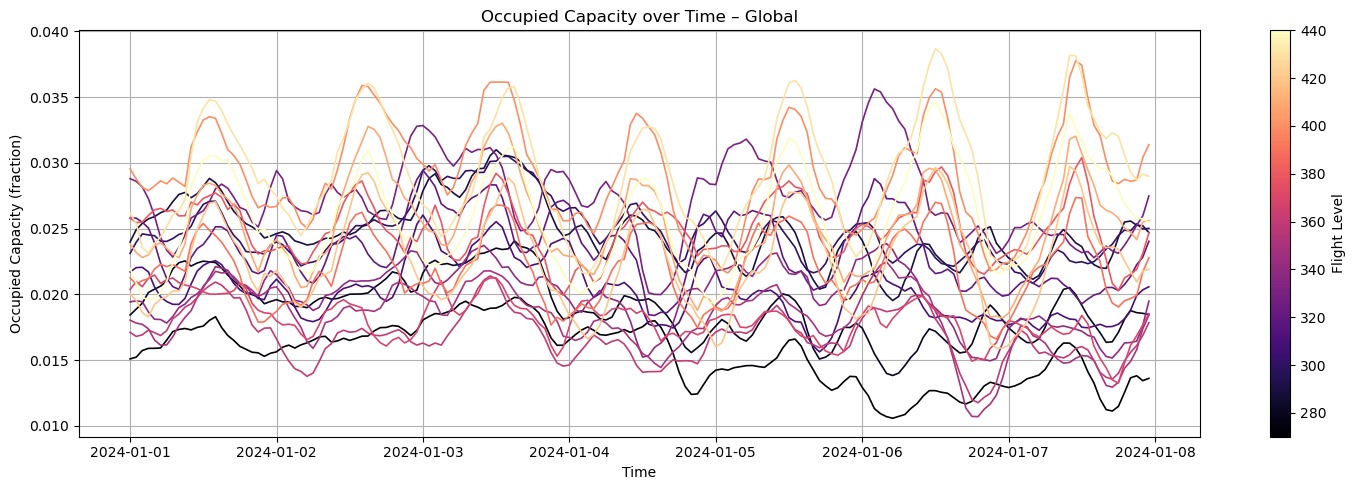

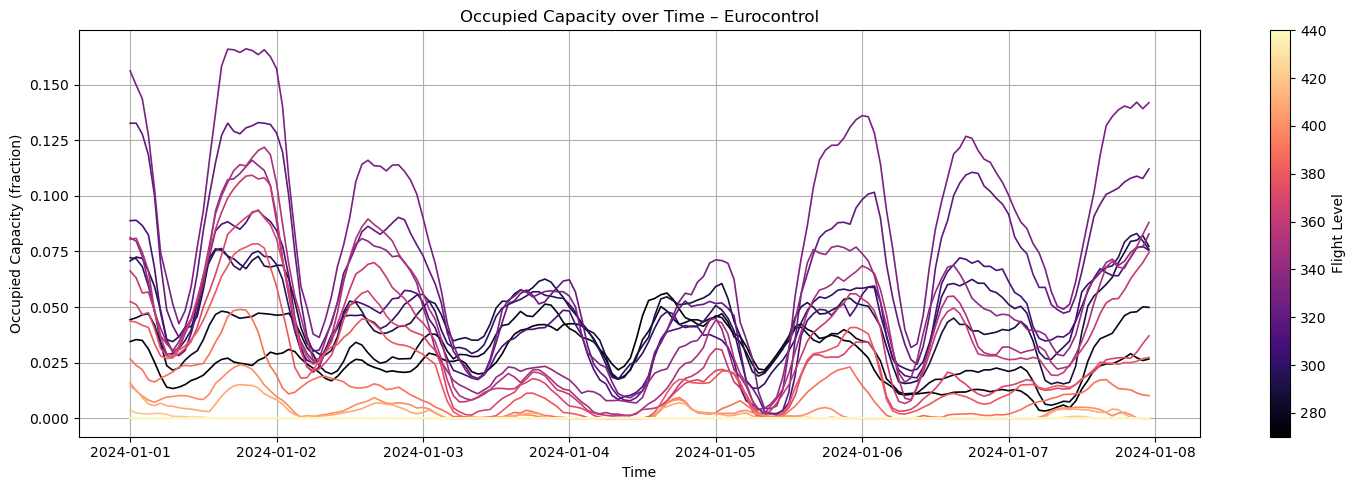

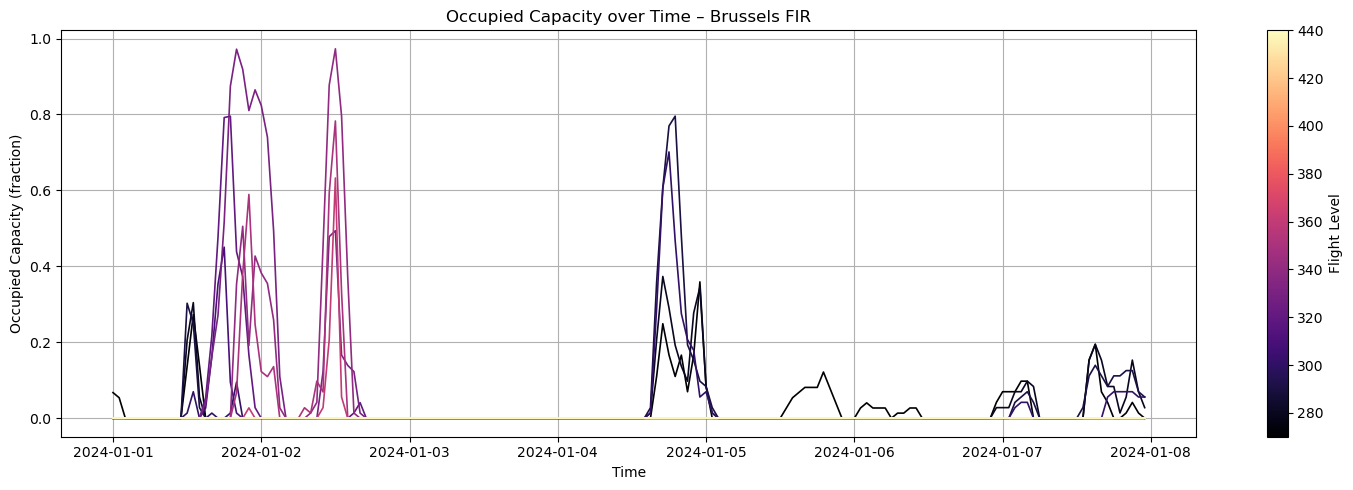

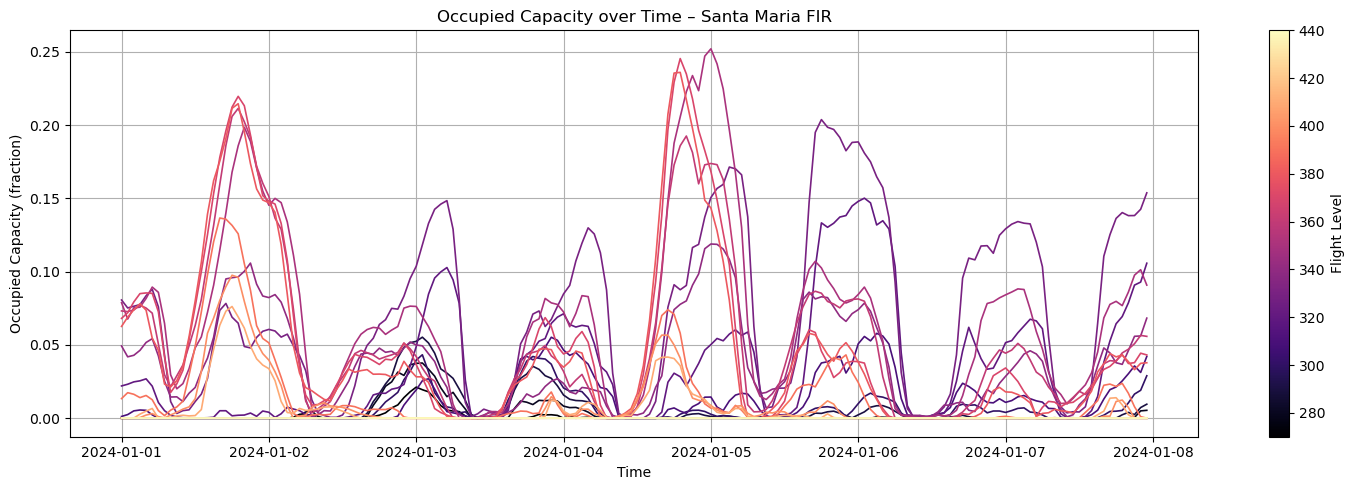

In [38]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

regions = ["Global", "Eurocontrol", "Brussels FIR", "Santa Maria FIR"]

# Define the colormap
cmap = plt.cm.magma

for region in regions:
    fig, ax = plt.subplots(figsize=(15, 5))
    region_data = df_capacity[df_capacity['region'] == region]

    # Ensure the time column is datetime and sorted
    region_data = region_data.sort_values('time')
    region_data['time'] = pd.to_datetime(region_data['time'])

    # Get unique flight levels and normalize for color mapping
    flight_levels = sorted(region_data['flight_level'].unique())
    norm = mpl.colors.Normalize(vmin=min(flight_levels), vmax=max(flight_levels))

    for case, grp in region_data.groupby('flight_level'):
        # Determine the color for this flight level
        color = cmap(norm(case))

        # Plot smoothed line (no legend)
        ax.plot(grp["time"][:7*24], grp['occupied_capacity'][:7*24], lw=1.2, color=color)

    # Add title and labels
    ax.set_title(f'Occupied Capacity over Time – {region}')
    ax.set_ylabel('Occupied Capacity (fraction)')
    ax.set_xlabel('Time')
    ax.grid(True)

    # Add colorbar for flight levels
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # only needed for the colorbar
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
    cbar.set_label('Flight Level')

    plt.tight_layout()
    plt.show()
